# MLP Classification on the Default of Credit Card Clients

In this example, we demonstrate how to:

- Load and preprocess the **Default of Credit Card Clients** dataset  
- Implement a **Multi-Layer Perceptron (MLP)** from scratch using NumPy  
- Train an MLP for **binary credit default prediction**  
- Evaluate the model using **classification accuracy**  
- Analyze why MLPs outperform linear models such as the Perceptron on structured financial data  

---

## Example: Default of Credit Card Clients Dataset

### Overview

The **Default of Credit Card Clients** dataset contains demographic and financial information of credit card holders in Taiwan.  
The objective is to predict whether a client will **default on their credit card payment in the next month**.

Unlike simple linear classification tasks, credit default behavior often involves **nonlinear interactions** between variables such as credit limits, repayment history, and bill amounts, making this dataset well-suited for nonlinear models such as MLPs.

---

### Data Source (Kaggle)

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

---

## Dataset Content

The dataset consists of **30,000 client records**, where each record includes:

- **Input features:** 25 variables describing client characteristics  
- **Target label:** default payment status in the next month  

### Label Definition

- `1` → Default  
- `0` → No default  

### Feature Categories

The input features include:

- Demographic variables (e.g., sex, education, marital status, age)  
- Credit limit information  
- Repayment status over previous months  
- Bill statement amounts  
- Payment amounts  

Each client is represented as a **25-dimensional feature vector**.

---

## Preprocessing

Before training the MLP model, the data is preprocessed as follows:

- Remove non-informative identifiers (e.g., client ID)  
- Separate the target variable from input features  
- Convert all features to numerical format  
- Standardize features to have zero mean and unit variance  
- Encode labels as binary values `{0, 1}`  

After preprocessing, the data is suitable for training a neural network using gradient-based optimization.

---

## Learning Task and Output

The learning task is a **supervised binary classification problem**:

> Given a client’s financial and demographic information, predict whether the client will default on their credit card payment next month.

In this implementation:

- The **input** is a standardized 25-dimensional feature vector  
- The **MLP model** applies one or more hidden layers with nonlinear activation functions  
- The **output layer** produces a single score representing default risk  
- A threshold (e.g., sigmoid + 0.5 cutoff) is used to convert scores into binary predictions  
- The model is evaluated using **classification accuracy** on a held-out test set  

---

## MLP Model Description

An MLP extends the linear Perceptron by introducing **hidden layers and nonlinear activation functions**.

A one-hidden-layer MLP can be written as:

$$
h = \sigma(W_1 x + b_1)
$$

$$
\hat{y} = \sigma(W_2 h + b_2)
$$

where:

- $x \in \mathbb{R}^{25}$ is the input feature vector  
- $h$ is the hidden representation  
- $\sigma(\cdot)$ is a nonlinear activation function (e.g., ReLU, tanh, sigmoid)  

This structure allows the model to learn **nonlinear decision boundaries** and **feature interactions**.

---

## Why MLPs Outperform Linear Models on Credit Data

Compared to a linear Perceptron, an MLP introduces a hidden layer that learns intermediate representations of the input features. This hidden layer can automatically capture nonlinear interactions and combinations of financial variables, such as joint effects of credit limit, repayment history, and payment behavior. As a result, the MLP is able to model more complex decision boundaries that better reflect real-world credit default mechanisms.

MLP offers several advantages:

- **Nonlinear modeling capacity**  
  Credit default risk depends on interactions between multiple variables, which cannot be captured by linear models.

- **Automatic feature combination**  
  Hidden layers can learn complex patterns such as threshold effects and joint risk factors.

- **Improved decision boundaries**  
  MLPs can separate overlapping classes more effectively than linear classifiers.

These properties make MLPs a natural extension when linear models reach a performance ceiling.

---

## Evaluation

Model performance is evaluated using **classification accuracy** on a test set:

$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of samples}}
$$

Accuracy reflects how well the model generalizes to unseen clients, though it may be complemented by other metrics (e.g., precision, recall) in imbalanced credit datasets.


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from MLP import SimpleMLP

import seaborn as sns
    

Epoch 1/20 - Train accuracy: 0.8074
Epoch 2/20 - Train accuracy: 0.8126
Epoch 3/20 - Train accuracy: 0.8172
Epoch 4/20 - Train accuracy: 0.8176
Epoch 5/20 - Train accuracy: 0.8180
Epoch 6/20 - Train accuracy: 0.8163
Epoch 7/20 - Train accuracy: 0.8160
Epoch 8/20 - Train accuracy: 0.8215
Epoch 9/20 - Train accuracy: 0.8180
Epoch 10/20 - Train accuracy: 0.8187
Epoch 11/20 - Train accuracy: 0.8178
Epoch 12/20 - Train accuracy: 0.8193
Epoch 13/20 - Train accuracy: 0.8219
Epoch 14/20 - Train accuracy: 0.8223
Epoch 15/20 - Train accuracy: 0.8225
Epoch 16/20 - Train accuracy: 0.8217
Epoch 17/20 - Train accuracy: 0.8212
Epoch 18/20 - Train accuracy: 0.8201
Epoch 19/20 - Train accuracy: 0.8225
Epoch 20/20 - Train accuracy: 0.8226

=== Results ===
Train Accuracy: 0.8226
Test  Accuracy: 0.8165


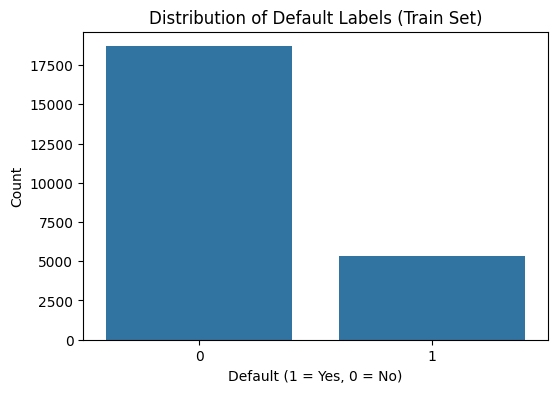

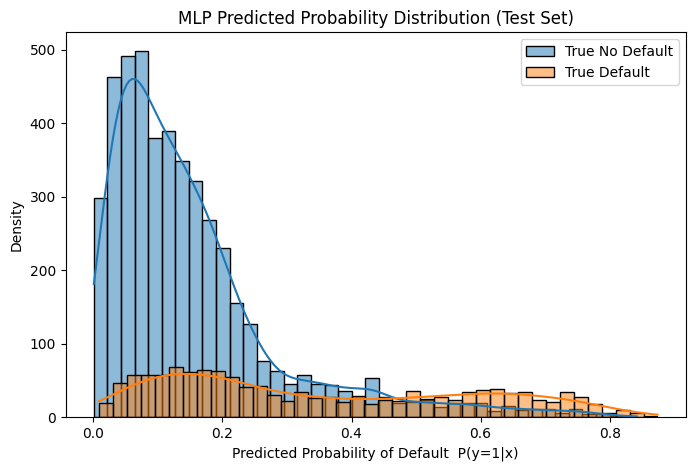

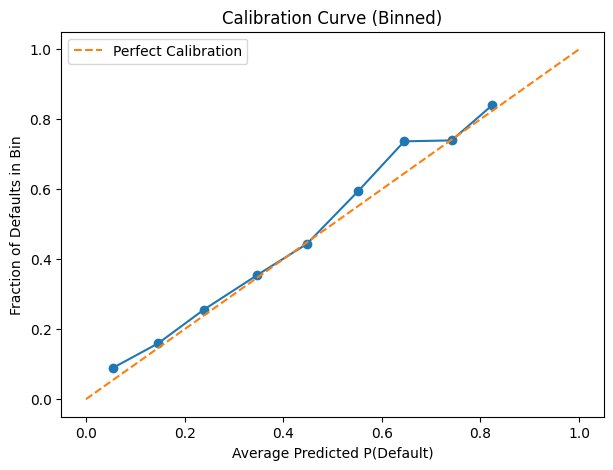

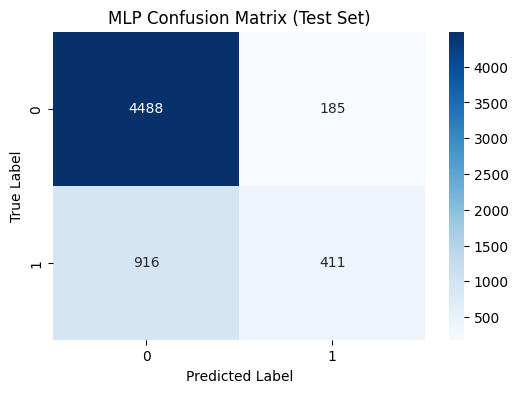

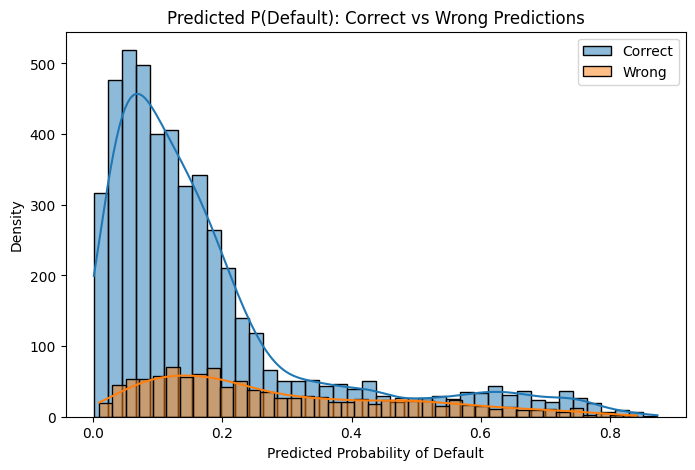

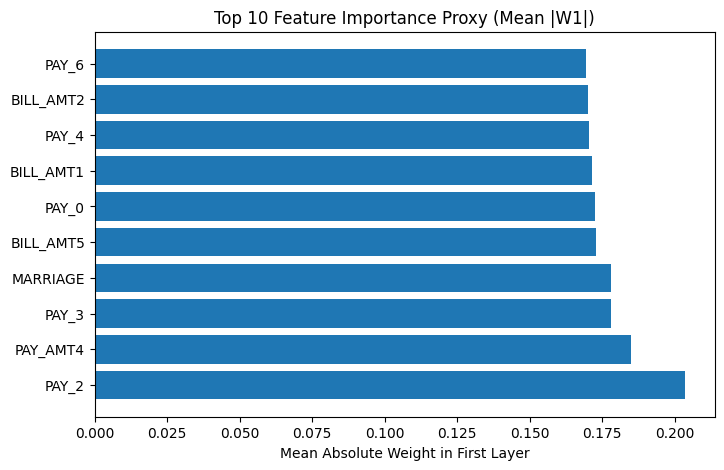

In [16]:
def load_credit_default(path):
    df = pd.read_csv(path)

    y = df["default.payment.next.month"].values.astype(int)

    X_df = df.drop(columns=["ID", "default.payment.next.month"])
    X = X_df.values.astype(np.float32)

    feature_names = list(X_df.columns)

    return X, y, feature_names



def main():
    # ========= 1. Load data =========
    X, y, feature_names = load_credit_default("/Users/lhe/Desktop/438/Perceptron/UCI_Credit_Card.csv")

    # ========= 2. Train / Test split =========
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # ========= 3. Standardization =========
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    input_dim = X_train.shape[1]

    # ========= 4. MLP =========
    mlp = SimpleMLP(
        input_dim=input_dim,
        hidden_dim=128,
        output_dim=10,   # IMPORTANT: must be 10 (aligned with one_hot)
        lr=0.01,
        momentum=0.9
    )

    mlp.train(
        X_train,
        y_train,
        epochs=20,
        batch_size=64
    )

    # ========= 5. Evaluation =========
    y_pred_train = mlp.predict(X_train)
    y_pred_test = mlp.predict(X_test)

    train_acc = np.mean(y_pred_train == y_train)
    test_acc = np.mean(y_pred_test == y_test)

    print("\n=== Results ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test  Accuracy: {test_acc:.4f}")

    # ===============================
    # 1. Label distribution
    # ===============================
    plt.figure(figsize=(6,4))
    sns.countplot(x=y_train)
    plt.title("Distribution of Default Labels (Train Set)")
    plt.xlabel("Default (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.show()


    # ===============================
    # 2. Predicted probability distribution
    #    (how confident is the MLP?)
    # ===============================
    probs_test = mlp.forward(X_test)          # (n, 2)
    p_default = probs_test[:, 1]                # P(y=1)

    plt.figure(figsize=(8,5))
    sns.histplot(p_default[y_test == 0], bins=40, label="True No Default", kde=True)
    sns.histplot(p_default[y_test == 1], bins=40, label="True Default", kde=True)
    plt.title("MLP Predicted Probability Distribution (Test Set)")
    plt.xlabel("Predicted Probability of Default  P(y=1|x)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()



    # ===============================
    # 3. Reliability-ish view:
    #    predicted probability vs true label (binned)
    # ===============================

    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(p_default, bins) - 1
    bin_centers = (bins[:-1] + bins[1:]) / 2

    avg_pred = []
    avg_true = []
    for k in range(len(bin_centers)):
        mask = bin_ids == k
        if np.any(mask):
            avg_pred.append(np.mean(p_default[mask]))
            avg_true.append(np.mean(y_test[mask]))

    plt.figure(figsize=(7,5))
    plt.plot(avg_pred, avg_true, marker='o')
    plt.plot([0,1], [0,1], linestyle='--', label="Perfect Calibration")
    plt.title("Calibration Curve (Binned)")
    plt.xlabel("Average Predicted P(Default)")
    plt.ylabel("Fraction of Defaults in Bin")
    plt.legend()
    plt.show()


    # ===============================
    # 4. Confusion matrix
    # ===============================
    y_pred_test = np.argmax(probs_test, axis=1)
    cm = confusion_matrix(y_test, y_pred_test)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("MLP Confusion Matrix (Test Set)")
    plt.show()


    # ===============================
    # 5. Error analysis:
    #    show probability distributions for correct vs wrong predictions
    # ===============================
    correct = (y_pred_test == y_test)

    plt.figure(figsize=(8,5))
    sns.histplot(p_default[correct], bins=40, label="Correct", kde=True)
    sns.histplot(p_default[~correct], bins=40, label="Wrong", kde=True)
    plt.title("Predicted P(Default): Correct vs Wrong Predictions")
    plt.xlabel("Predicted Probability of Default")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


    # ===============================
    # 6. First-layer weight magnitude (feature importance proxy)
    #    |W1| aggregated over hidden units
    # ===============================
    # W1 shape: (n_features, hidden_dim)
    w1_mag = np.mean(np.abs(mlp.W1), axis=1)

    idx = np.argsort(w1_mag)[-10:]
    top_vals = w1_mag[idx]
    top_names = [feature_names[i] for i in idx]

    plt.figure(figsize=(8,5))
    plt.barh(top_names, top_vals)
    plt.title("Top 10 Feature Importance Proxy (Mean |W1|)")
    plt.xlabel("Mean Absolute Weight in First Layer")
    plt.gca().invert_yaxis()
    plt.show()



if __name__ == "__main__":
    main()

## Discussion

The Multi-Layer Perceptron (MLP) achieves a training accuracy of 82.26% and a test accuracy of 81.65%, representing a clear improvement over the linear Perceptron model.  
The relatively small gap between training and test accuracy indicates that the increased model capacity does not lead to severe overfitting and that the learned patterns generalize well to unseen data.

The predicted probability distribution on the test set shows that the MLP is able to separate default and non-default clients more effectively in probability space. Non-default clients are largely assigned low predicted probabilities of default (concentrated below 0.3), while default clients exhibit a right-shifted distribution with substantially higher predicted probabilities. Although some overlap remains—reflecting the inherent ambiguity of real-world credit behavior—the separation is noticeably stronger than that achieved by a linear classifier.

The calibration curve further demonstrates that the MLP’s probability outputs are well aligned with empirical default frequencies. Across most probability bins, the average predicted probability closely matches the observed fraction of defaults, indicating that the model is not only accurate but also well-calibrated. This is particularly important in credit risk modeling, where probabilistic risk estimates are often more informative than hard classification decisions.

Error analysis reveals that incorrect predictions are primarily concentrated in regions with intermediate predicted probabilities.  
In contrast, predictions with very low or very high estimated default risk are more likely to be correct.  
This pattern suggests that the model’s confidence is meaningful and that misclassifications arise from intrinsically difficult cases rather than random noise.

---

## Conclusion

This project demonstrates the application of a Multi-Layer Perceptron to the Default of Credit Card Clients dataset and highlights its advantages over linear classification approaches. By introducing nonlinear hidden layers, the MLP overcomes key limitations of the Perceptron and is able to model complex interactions among repayment behavior, bill amounts, and demographic characteristics.

The resulting model achieves higher predictive accuracy and produces well-calibrated probability estimates, making it more suitable for practical credit risk assessment. At the same time, analysis of prediction confidence and feature usage shows that the model’s behavior remains interpretable at a high level.

Overall, the MLP represents a meaningful step toward more realistic and effective credit default modeling, balancing improved performance with generalization and interpretability.
